# Student Habits CSE 4095 Assignment With Scikit-Learn

# Part 0 — Start a Notebook and Insepct the Dataset

In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('../assignment7/class1_student_habits.csv')
df.head()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,quiz_average,exam_score
0,S001,1.3,7.7,71.8,8,Strong,No,0,67.0,64.6
1,S002,9.4,6.6,74.2,14,NaN,Yes,52,74.8,81.5
2,S003,11.2,6.1,70.3,15,Some,No,7,99.1,92.0
3,S004,10.8,7.6,77.1,16,Strong,No,12,86.4,100.0
4,S005,8.0,5.6,89.7,15,NaN,Yes,12,75.7,68.5


In [40]:
print('Rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

Rows and columns: (250, 10)

Column names:
['student_id', 'study_hours_per_week', 'sleep_hours_per_night', 'attendance_rate', 'practice_problems_per_week', 'prior_programming_experience', 'study_group', 'commute_minutes', 'quiz_average', 'exam_score']

Data types:
student_id                       object
study_hours_per_week            float64
sleep_hours_per_night           float64
attendance_rate                 float64
practice_problems_per_week        int64
prior_programming_experience     object
study_group                      object
commute_minutes                   int64
quiz_average                    float64
exam_score                      float64
dtype: object

Missing values per column:
student_id                       0
study_hours_per_week             9
sleep_hours_per_night           12
attendance_rate                  0
practice_problems_per_week       0
prior_programming_experience    95
study_group                      0
commute_minutes                  0
quiz_average 

# Part 1 — Define a Classification Problem

,Count,Percentage
high_exam_score,,
Yes,99,39.6
No,151,60.4


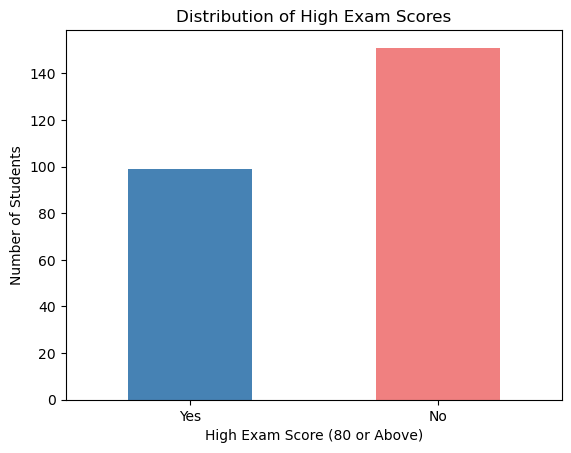

In [41]:
import matplotlib.pyplot as plt

# Create the binary target: a score of 80 or above is considered high.
df['high_exam_score'] = np.where(df['exam_score'] >= 80, 'Yes', 'No')

# Count each class and calculate its share of all students.
class_distribution = df['high_exam_score'].value_counts().reindex(['Yes', 'No'])
class_percentages = df['high_exam_score'].value_counts(normalize=True).reindex(['Yes', 'No']) * 100
distribution_summary = pd.DataFrame({
    'Count': class_distribution,
    'Percentage': class_percentages.round(1)
})
display(distribution_summary)

# Visualize the number of students in each class.
class_distribution.plot(kind='bar', color=['steelblue', 'lightcoral'])
plt.title('Distribution of High Exam Scores')
plt.xlabel('High Exam Score (80 or Above)')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

Predicting exam_score is a regression problem because the target is a continuous number that can take many values (64.6 or 92.0). Predicting high_exam_score is a classification problem because the target is a category, "Yes" or "No". The dataset has 99 students in the Yes class (39.6%) and 151 in the No class (60.4%), so the classes are moderately imbalanced but not severely. The bar chart above shows this distribution.

# Part 2 — Choose the Features

In [42]:
# Select the predictors (X) and the classification target (y).
feature_columns = [
    'study_hours_per_week',
    'sleep_hours_per_night',
    'attendance_rate',
    'practice_problems_per_week',
    'prior_programming_experience',
    'study_group',
    'commute_minutes'
]

X = df[feature_columns]
y = df['high_exam_score']

numerical_features = [
    'study_hours_per_week',
    'sleep_hours_per_night',
    'attendance_rate',
    'practice_problems_per_week',
    'commute_minutes'
]

categorical_features = [
    'prior_programming_experience',
    'study_group'
]

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)
print('\nX shape:', X.shape)
print('y shape:', y.shape)

Numerical features: ['study_hours_per_week', 'sleep_hours_per_night', 'attendance_rate', 'practice_problems_per_week', 'commute_minutes']
Categorical features: ['prior_programming_experience', 'study_group']

X shape: (250, 7)
y shape: (250,)


student_id should not be a predictor because it is only a label for identifying a student; it does not measure any habit or ability, so any pattern the model found in IDs would be accidental. Using exam_score to predict high_exam_score would be a serious problem because high_exam_score was created directly from exam_score (>= 80), so the model would effectively be given the answer. This is target leakage and would produce unrealistically high results that would not reflect real prediction.

# Part 3 — Split the Data

In [43]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the Yes/No class balance similar in the train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

def show_class_balance(labels, name):
    counts = labels.value_counts().reindex(['Yes', 'No'])
    proportions = (labels.value_counts(normalize=True)
                   .reindex(['Yes', 'No'])
                   .mul(100)
                   .round(1))
    summary = pd.DataFrame({'Count': counts, 'Percentage': proportions})
    print(f'\n{name} class distribution:')
    display(summary)

show_class_balance(y_train, 'Training set')
show_class_balance(y_test, 'Test set')


Training set class distribution:


,Count,Percentage
high_exam_score,,
Yes,79,39.5
No,121,60.5



Test set class distribution:


,Count,Percentage
high_exam_score,,
Yes,20,40.0
No,30,60.0


The training set is the data the model learns from, using the students' features and known labels. The test set is held back to act like new, unseen students so I can estimate how well the model works beyond the data it learned from. Stratification splits each class proportionally so the training and test sets keep about the same Yes/No balance as the full dataset; I used stratify=y, which gave 79 Yes / 121 No in training (200 students) and 20 Yes / 30 No in test (50 students). We shouldn't train on the test data because then the model would have already seen the answers, and its test performance would look better than it really is.

# Part 4 — Establish a Baseline

In [44]:
from sklearn.dummy import DummyClassifier

# Find the class that occurs most often in the training labels.
majority_class = y_train.value_counts().idxmax()
print('Majority class in y_train:', majority_class)

# By hand: predict the majority class for every test student, then count correct predictions.
hand_correct = (y_test == majority_class).sum()
hand_accuracy = hand_correct / len(y_test)
print(f'By hand: {hand_correct} correct out of {len(y_test)} test students')
print(f'By-hand accuracy: {hand_accuracy:.1%}')

# DummyClassifier makes the same most-frequent-class prediction automatically.
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
dummy_accuracy = dummy_model.score(X_test, y_test)
print(f'DummyClassifier accuracy: {dummy_accuracy:.1%}')

print('Results match:', hand_accuracy == dummy_accuracy)

Majority class in y_train: No
By hand: 30 correct out of 50 test students
By-hand accuracy: 60.0%
DummyClassifier accuracy: 60.0%
Results match: True


The majority class in the training data is "No" (121 of 200 students). A classifier that predicts "No" for every test student is correct for 30 of 50 students, giving a baseline accuracy of 60.0%, which I confirmed by hand and with DummyClassifier. This baseline is useful because a real model should beat it; otherwise it isn't adding value over a trivial rule. It also shows that accuracy alone can mislead, since this baseline never predicts "Yes" and so has 0% recall for the Yes class.

# Part 5 — Preprocess the Data

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical data: fill missing values with the training-column median, then scale values.
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical data: fill missing values with the most frequent training category,
# then turn each category into one or more 0/1 indicator columns.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Learn imputation, scaling, and category information from the training data only.
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print('Prepared X_train shape:', X_train_prepared.shape)
print('Prepared X_test shape:', X_test_prepared.shape)

Prepared X_train shape: (200, 9)
Prepared X_test shape: (50, 9)


In [46]:
# Keep missing experience as its own group for this comparison.
experience_groups = df.assign(
    experience_group=df['prior_programming_experience'].fillna('Missing')
)

experience_score_summary = (
    experience_groups.groupby('experience_group')['exam_score']
    .agg(Students='size', Mean='mean', Median='median')
    .reindex(['Some', 'Strong', 'Missing'])
    .round(1)
)

display(experience_score_summary)

,Students,Mean,Median
experience_group,,,
Some,107,77.9,78.3
Strong,48,81.3,83.2
Missing,95,74.3,74.8


Categorical variables must be converted because Logistic Regression does math on numbers and cannot use text such as "Yes" or "Strong" directly. One-hot encoding turns each category into its own 0/1 column (e.g., study_group_No and study_group_Yes), which avoids inventing an artificial numeric order between categories. Missing values must be handled because Logistic Regression generally cannot train on NaN values; the imputer fills them using a rule learned from the training data (median for numerical, most frequent category for categorical). StandardScaler rescales each numerical feature by subtracting the training mean and dividing by the training standard deviation, so features with different units are on a comparable scale.

# Part 6 — Understand Data Scaling

In [47]:
# The feature names show the five numerical columns and four one-hot-encoded columns.
output_feature_names = preprocessor.get_feature_names_out()
print('Output column names:')
print(output_feature_names)

# The first five output columns are the scaled numerical features.
train_numeric_scaled = X_train_prepared[:, :len(numerical_features)]
test_numeric_scaled = X_test_prepared[:, :len(numerical_features)]

scaling_check = pd.DataFrame({
    'Train mean': train_numeric_scaled.mean(axis=0),
    'Train std': train_numeric_scaled.std(axis=0),
    'Test mean': test_numeric_scaled.mean(axis=0),
    'Test std': test_numeric_scaled.std(axis=0)
}, index=numerical_features).round(3)

display(scaling_check)

Output column names:
['num__study_hours_per_week' 'num__sleep_hours_per_night'
 'num__attendance_rate' 'num__practice_problems_per_week'
 'num__commute_minutes' 'cat__prior_programming_experience_Some'
 'cat__prior_programming_experience_Strong' 'cat__study_group_No'
 'cat__study_group_Yes']


,Train mean,Train std,Test mean,Test std
study_hours_per_week,-0.0,1.0,0.151,1.025
sleep_hours_per_night,0.0,1.0,-0.165,0.946
attendance_rate,0.0,1.0,0.050,0.959
practice_problems_per_week,-0.0,1.0,0.063,0.763
commute_minutes,0.0,1.0,-0.115,0.791


Scaling can be useful for Logistic Regression because features like commute minutes and attendance percentage have very different ranges, and scaling makes the coefficient fitting more stable and the coefficients easier to compare. No, standardization does not make values fall between 0 and 1; standardized values can be negative or larger than 1 because they are measured in standard deviations from the training mean. The test set should not be used to compute the mean and standard deviation because that would let information from the supposedly unseen students influence the preprocessing, making the evaluation less trustworthy. I confirmed this: the training columns had mean about 0 and standard deviation about 1, while the test columns were close but not exactly 0 and 1.

# Part 7 — Train a Logistic Regression Classifier

In [48]:
from sklearn.linear_model import LogisticRegression

# The pipeline preprocesses raw inputs first, then trains Logistic Regression.
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit every step using raw training features and their known labels.
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


.fit() means "learn from these labeled training examples." From the training data the pipeline learns the median and most frequent values for the imputers, the mean and standard deviation for the scaler, the categories seen by the one-hot encoder, and the coefficients that relate the processed features to the chance of "Yes." Putting preprocessing and the classifier in one pipeline keeps the steps in the correct order and automatically applies the same training-derived settings to test data, which helps prevent leakage and inconsistent preprocessing.

# Part 8 — Make Predictions

In [49]:
# Predict classes for the raw test features.
test_predictions = logistic_pipeline.predict(X_test)

# student_id is included here only to identify rows in the results; it was not used to train.
test_student_ids = df.loc[X_test.index, 'student_id']
actual_vs_predicted = pd.DataFrame({
    'student_id': test_student_ids,
    'actual_class': y_test,
    'predicted_class': test_predictions
})

print('Actual versus predicted class (first 10 test students):')
display(actual_vs_predicted.head(10))

# Use the learned class order to locate the probability column for Yes.
print('Pipeline class order:', logistic_pipeline.classes_)
yes_column_index = list(logistic_pipeline.classes_).index('Yes')
test_probabilities = logistic_pipeline.predict_proba(X_test)

actual_predicted_with_probability = actual_vs_predicted.copy()
actual_predicted_with_probability['predicted_probability_yes'] = (
    test_probabilities[:, yes_column_index]
).round(3)

print('Actual class, predicted class, and predicted probability of Yes (first 10):')
display(actual_predicted_with_probability.head(10))

Actual versus predicted class (first 10 test students):


,student_id,actual_class,predicted_class
113,S114,Yes,No
153,S154,No,No
216,S217,No,No
241,S242,No,No
31,S032,No,No
80,S081,Yes,Yes
140,S141,Yes,No
164,S165,No,No
77,S078,Yes,Yes
4,S005,No,No


Pipeline class order: ['No' 'Yes']
Actual class, predicted class, and predicted probability of Yes (first 10):


,student_id,actual_class,predicted_class,predicted_probability_yes
113,S114,Yes,No,0.368
153,S154,No,No,0.107
216,S217,No,No,0.207
241,S242,No,No,0.291
31,S032,No,No,0.367
80,S081,Yes,Yes,0.646
140,S141,Yes,No,0.374
164,S165,No,No,0.213
77,S078,Yes,Yes,0.831
4,S005,No,No,0.280


predict() returns the model's final class decision ("Yes" or "No"), while predict_proba() returns the estimated probability of each class; I used pipeline.classes_ to confirm which column was "Yes". A predicted probability near 0.5 suggests the model is uncertain and the student is close to its decision boundary. A probability near 0.95 suggests the model is very confident the student is "Yes," although a confident prediction can still be wrong.

# Part 9 — Evaluate the Classifier

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Evaluate the test-set predictions, treating high exam score = Yes as positive.
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision_yes = precision_score(y_test, test_predictions, pos_label='Yes')
test_recall_yes = recall_score(y_test, test_predictions, pos_label='Yes')

# The majority baseline always predicts No, so it cannot find any actual Yes cases.
baseline_predictions = [majority_class] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_recall_yes = recall_score(
    y_test, baseline_predictions, pos_label='Yes', zero_division=0
)

metric_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision for Yes', 'Recall for Yes', 'Majority-baseline recall for Yes'],
    'Value': [test_accuracy, test_precision_yes, test_recall_yes, baseline_recall_yes]
})
metric_summary['Value'] = metric_summary['Value'].map(lambda value: f'{value:.1%}')
display(metric_summary)

print(f'Logistic Regression accuracy: {test_accuracy:.1%}')
print(f'Majority-class baseline accuracy: {baseline_accuracy:.1%}')

,Metric,Value
0,Accuracy,84.0%
1,Precision for Yes,83.3%
2,Recall for Yes,75.0%
3,Majority-baseline recall for Yes,0.0%


Logistic Regression accuracy: 84.0%
Majority-class baseline accuracy: 60.0%


The model's test accuracy was 84.0%, meaning it classified 84% of all test students correctly, compared with 60.0% for the majority-class baseline. Precision for Yes was 83.3%, meaning that when the model predicts a high exam score it is right about 83% of the time. Recall for Yes was 75.0%, meaning the model identified 75% of the students who actually had a high exam score (the baseline's recall is 0%). The model clearly beats the baseline, though with only 50 test students each student is worth 2 percentage points.

# Part 10 — Understand the Confusion Matrix

In [51]:
from sklearn.metrics import confusion_matrix

# Rows are actual classes and columns are predicted classes, in the requested order.
class_order = ['No', 'Yes']
confusion = confusion_matrix(y_test, test_predictions, labels=class_order)
confusion_table = pd.DataFrame(
    confusion,
    index=['Actual No', 'Actual Yes'],
    columns=['Predicted No', 'Predicted Yes']
)
display(confusion_table)

tn, fp, fn, tp = confusion.ravel()
print(f'TN (actual No, predicted No): {tn}')
print(f'FP (actual No, predicted Yes): {fp}')
print(f'FN (actual Yes, predicted No): {fn}')
print(f'TP (actual Yes, predicted Yes): {tp}')

,Predicted No,Predicted Yes
Actual No,27,3
Actual Yes,5,15


TN (actual No, predicted No): 27
FP (actual No, predicted Yes): 3
FN (actual Yes, predicted No): 5
TP (actual Yes, predicted Yes): 15


The confusion matrix has 27 true negatives, 3 false positives, 5 false negatives, and 15 true positives, so the model produced 3 false positives and 5 false negatives. A false positive means the model predicted a student would earn a high exam score (80+) but the student did not; a false negative means the model predicted "No" for a student who actually scored 80 or above. Which error is worse depends on how the prediction is used: if it were used to identify students who might need extra help, a false positive would be more costly because it would wrongly label a struggling student as doing well.

# Part 11 — Inspect Individual Errors

In [52]:
# Keep original test features alongside actual labels, predictions, and probabilities.
test_results = X_test.copy()
test_results.insert(0, 'student_id', df.loc[X_test.index, 'student_id'])
test_results.insert(1, 'actual_class', y_test)
test_results.insert(2, 'predicted_class', test_predictions)
test_results.insert(3, 'probability_yes', test_probabilities[:, yes_column_index].round(3))

false_positives = test_results[
    (test_results['actual_class'] == 'No') & (test_results['predicted_class'] == 'Yes')
]
false_negatives = test_results[
    (test_results['actual_class'] == 'Yes') & (test_results['predicted_class'] == 'No')
]

display_columns = [
    'student_id', 'actual_class', 'predicted_class', 'probability_yes',
    *feature_columns
]
print(f'False positives: {len(false_positives)}')
display(false_positives[display_columns])
print(f'False negatives: {len(false_negatives)}')
display(false_negatives[display_columns])

# Compare numerical averages only: calculating an average of text categories is not meaningful.
correct_predictions = test_results[
    test_results['actual_class'] == test_results['predicted_class']
]
correct_numeric_averages = correct_predictions[numerical_features].mean().round(2)
print('Average numerical feature values for correctly classified test students:')
display(correct_numeric_averages.to_frame('Average'))

print('Categorical-feature distributions for correctly classified test students:')
for feature in categorical_features:
    print(f'\n{feature}:')
    display(correct_predictions[feature].fillna('Missing').value_counts().to_frame('Count'))

missingness_columns = [
    'study_hours_per_week', 'sleep_hours_per_night', 'prior_programming_experience'
]
mistakes = pd.concat([false_positives, false_negatives])
mistake_missingness = mistakes[missingness_columns].isna().sum().to_frame('Missing among mistakes')
mistake_missingness['Total mistakes'] = len(mistakes)
display(mistake_missingness)

False positives: 3


,student_id,actual_class,predicted_class,probability_yes,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes
175,S176,No,Yes,0.549,12.7,7.3,74.0,13,NaN,No,15
169,S170,No,Yes,0.683,9.4,7.5,98.3,19,NaN,No,45
156,S157,No,Yes,0.502,7.5,6.9,91.9,23,NaN,Yes,21


False negatives: 5


,student_id,actual_class,predicted_class,probability_yes,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes
113,S114,Yes,No,0.368,10.3,6.0,89.5,9,Some,No,38
140,S141,Yes,No,0.374,9.4,7.0,82.8,13,Some,No,31
37,S038,Yes,No,0.233,5.5,7.1,78.3,22,Some,Yes,19
89,S090,Yes,No,0.345,NaN,6.2,72.7,15,Strong,No,28
99,S100,Yes,No,0.242,5.7,7.2,82.7,19,NaN,No,14


Average numerical feature values for correctly classified test students:


...

Categorical-feature distributions for correctly classified test students:

prior_programming_experience:


,Count
prior_programming_experience,
Some,18
Missing,17
Strong,7



study_group:


,Count
study_group,
Yes,26
No,16


,Missing among mistakes,Total mistakes
study_hours_per_week,1,8
sleep_hours_per_night,0,8
prior_programming_experience,4,8


Of the 8 mistakes, 3 were false positives (predicted probabilities about 0.50-0.68) and 5 were false negatives (about 0.23-0.37). All 3 false positives had a missing prior_programming_experience value, and each had a relatively strong habit feature (S176 studied 12.7 hours/week; S170 and S157 had attendance above 90%) but did not reach 80. Several false negatives, such as S038 and S100 (about 5.5 hours of study per week), had modest habit values but scored 80 or above. One hypothesis is that the model relies on general effort-related patterns, so students whose scores don't follow those patterns are hard to classify, and the missing programming-experience values may also make some students harder to classify. These are only hypotheses from a very small number of errors, and other factors not in the data could explain the results.

# Part 12 — Target Leakage Experiment

In [53]:
# DEMONSTRATION ONLY: exam_score must not be used in a valid high_exam_score model.
leakage_feature_columns = feature_columns + ['exam_score']
leakage_numerical_features = numerical_features + ['exam_score']

# Use the same train/test student rows as the legitimate experiment.
X_train_leakage = df.loc[X_train.index, leakage_feature_columns]
X_test_leakage = df.loc[X_test.index, leakage_feature_columns]

leakage_numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
leakage_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

leakage_preprocessor = ColumnTransformer(transformers=[
    ('num', leakage_numerical_transformer, leakage_numerical_features),
    ('cat', leakage_categorical_transformer, categorical_features)
])

leakage_pipeline = Pipeline(steps=[
    ('preprocessor', leakage_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

leakage_pipeline.fit(X_train_leakage, y_train)
leakage_predictions = leakage_pipeline.predict(X_test_leakage)

leakage_accuracy = accuracy_score(y_test, leakage_predictions)
leakage_precision_yes = precision_score(y_test, leakage_predictions, pos_label='Yes')
leakage_recall_yes = recall_score(y_test, leakage_predictions, pos_label='Yes')

print(f'Leaky-model accuracy: {leakage_accuracy:.1%}')
print(f'Leaky-model precision for Yes: {leakage_precision_yes:.1%}')
print(f'Leaky-model recall for Yes: {leakage_recall_yes:.1%}')
print(f'Legitimate-model accuracy: {test_accuracy:.1%}')

Leaky-model accuracy: 98.0%
Leaky-model precision for Yes: 100.0%
Leaky-model recall for Yes: 95.0%
Legitimate-model accuracy: 84.0%


In [54]:
# Inspect any test rows the demonstration-only leaky model got wrong.
leakage_yes_column_index = list(leakage_pipeline.classes_).index('Yes')
leakage_probabilities = leakage_pipeline.predict_proba(X_test_leakage)

leakage_results = pd.DataFrame({
    'student_id': df.loc[X_test.index, 'student_id'],
    'exam_score': X_test_leakage['exam_score'],
    'actual_class': y_test,
    'predicted_class': leakage_predictions,
    'probability_yes': leakage_probabilities[:, leakage_yes_column_index].round(3)
})

leakage_errors = leakage_results[
    leakage_results['actual_class'] != leakage_results['predicted_class']
]
display(leakage_errors)

if not leakage_errors.empty:
    cutoff_distance = (leakage_errors['exam_score'] - 80).abs()
    print('Distance from the 80-point cutoff:')
    display(cutoff_distance.to_frame('points_from_80'))

,student_id,exam_score,actual_class,predicted_class,probability_yes
37,S038,80.1,Yes,No,0.497


Distance from the 80-point cutoff:


,points_from_80
37,0.1


The accuracy rose from 84.0% for the legitimate model to 98.0% for the model that included exam_score (precision 100%, recall 95%). This happened because high_exam_score was defined directly as exam_score >= 80, so the model was effectively given the answer. The one mistake was a student with a score of 80.1, right at the cutoff, where the smooth logistic curve gave a probability of 0.497. The model is invalid even with very high accuracy because exam_score would not be available when we actually want to predict who will score highly, so this is target leakage.

# Part 13 — A Legitimate Feature Experiment

Prediction: I expect adding quiz average to increase accuracy and recall for "Yes" because quiz performance reflects how well students understand the course material, which likely relates closely to exam performance. Students who score high on quizzes should be easier for the model to identify as likely high scorers, especially the high-scoring students with modest study habits that my original model missed.

Result: Adding quiz_average did not improve the model. Accuracy fell from 84.0% to 82.0%, precision for Yes fell from 83.3% to 78.9%, and recall stayed at 75.0%, so my prediction was not supported on this test split. Three predictions changed from wrong to right and four from right to wrong, a net loss of one student, so the difference is small and may be noise with only 50 test students.

Availability: Whether quiz_average is available depends on when the prediction is made; if the goal is to predict before the exam but before quizzes are complete, it would not be available and would be inappropriate. A feature can be statistically useful yet inappropriate if it would not be known at the time the real prediction must be made, because the model would then rely on information from the future.

In [55]:
# This is a separate valid experiment: quiz_average is included, but exam_score remains excluded.
quiz_feature_columns = feature_columns + ['quiz_average']
quiz_numerical_features = numerical_features + ['quiz_average']

# Preserve the exact same train/test student rows as the original experiment.
X_train_quiz = df.loc[X_train.index, quiz_feature_columns]
X_test_quiz = df.loc[X_test.index, quiz_feature_columns]

quiz_numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
quiz_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
quiz_preprocessor = ColumnTransformer(transformers=[
    ('num', quiz_numerical_transformer, quiz_numerical_features),
    ('cat', quiz_categorical_transformer, categorical_features)
])

quiz_pipeline = Pipeline(steps=[
    ('preprocessor', quiz_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
quiz_pipeline.fit(X_train_quiz, y_train)
quiz_predictions = quiz_pipeline.predict(X_test_quiz)

quiz_accuracy = accuracy_score(y_test, quiz_predictions)
quiz_precision_yes = precision_score(y_test, quiz_predictions, pos_label='Yes')
quiz_recall_yes = recall_score(y_test, quiz_predictions, pos_label='Yes')

comparison = pd.DataFrame({
    'Model': ['Original model', 'Model with quiz_average'],
    'Accuracy': [test_accuracy, quiz_accuracy],
    'Precision for Yes': [test_precision_yes, quiz_precision_yes],
    'Recall for Yes': [test_recall_yes, quiz_recall_yes]
})
for column in ['Accuracy', 'Precision for Yes', 'Recall for Yes']:
    comparison[column] = comparison[column].map(lambda value: f'{value:.1%}')
display(comparison)

original_confusion = confusion_matrix(y_test, test_predictions, labels=['No', 'Yes'])
quiz_confusion = confusion_matrix(y_test, quiz_predictions, labels=['No', 'Yes'])
print('Original-model confusion matrix (rows: actual; columns: predicted):')
display(pd.DataFrame(original_confusion, index=['Actual No', 'Actual Yes'],
                     columns=['Predicted No', 'Predicted Yes']))
print('Quiz-average-model confusion matrix (rows: actual; columns: predicted):')
display(pd.DataFrame(quiz_confusion, index=['Actual No', 'Actual Yes'],
                     columns=['Predicted No', 'Predicted Yes']))

original_false_negative_ids = ['S114', 'S141', 'S038', 'S090', 'S100']
quiz_prediction_by_id = pd.Series(quiz_predictions, index=df.loc[X_test.index, 'student_id'])
false_negative_check = pd.DataFrame({
    'student_id': original_false_negative_ids,
    'quiz_model_prediction': quiz_prediction_by_id.reindex(original_false_negative_ids).values
})
false_negative_check['now_correctly_classified'] = (
    false_negative_check['quiz_model_prediction'] == 'Yes'
)
display(false_negative_check)

,Model,Accuracy,Precision for Yes,Recall for Yes
0,Original model,84.0%,83.3%,75.0%
1,Model with quiz_average,82.0%,78.9%,75.0%


Original-model confusion matrix (rows: actual; columns: predicted):


,Predicted No,Predicted Yes
Actual No,27,3
Actual Yes,5,15


Quiz-average-model confusion matrix (rows: actual; columns: predicted):


,Predicted No,Predicted Yes
Actual No,26,4
Actual Yes,5,15


,student_id,quiz_model_prediction,now_correctly_classified
0,S114,No,False
1,S141,Yes,True
2,S038,No,False
3,S090,No,False
4,S100,No,False


In [56]:
# Obtain the Yes-probability column from the quiz model's learned class order.
quiz_yes_column_index = list(quiz_pipeline.classes_).index('Yes')
quiz_probabilities = quiz_pipeline.predict_proba(X_test_quiz)

prediction_comparison = pd.DataFrame({
    'student_id': df.loc[X_test.index, 'student_id'],
    'actual_class': y_test,
    'original_prediction': test_predictions,
    'original_probability_yes': test_probabilities[:, yes_column_index].round(3),
    'quiz_prediction': quiz_predictions,
    'quiz_probability_yes': quiz_probabilities[:, quiz_yes_column_index].round(3),
    'quiz_average': X_test_quiz['quiz_average']
})

changed_predictions = prediction_comparison[
    prediction_comparison['original_prediction'] != prediction_comparison['quiz_prediction']
].copy()

changed_predictions['change_result'] = np.select(
    [
        (changed_predictions['original_prediction'] != changed_predictions['actual_class'])
        & (changed_predictions['quiz_prediction'] == changed_predictions['actual_class']),
        (changed_predictions['original_prediction'] == changed_predictions['actual_class'])
        & (changed_predictions['quiz_prediction'] != changed_predictions['actual_class'])
    ],
    ['Wrong to right', 'Right to wrong'],
    default='Changed, but neither improved nor worsened'
)

display(changed_predictions)
print('Number of changed predictions by outcome:')
display(changed_predictions['change_result'].value_counts().to_frame('Count'))

,student_id,actual_class,original_prediction,original_probability_yes,quiz_prediction,quiz_probability_yes,quiz_average,change_result
31,S032,No,No,0.367,Yes,0.549,84.1,Right to wrong
140,S141,Yes,No,0.374,Yes,0.818,92.5,Wrong to right
29,S030,No,No,0.430,Yes,0.537,83.1,Right to wrong
169,S170,No,Yes,0.683,No,0.265,69.7,Wrong to right
234,S235,No,No,0.446,Yes,0.769,90.2,Right to wrong
114,S115,Yes,Yes,0.609,No,0.277,75.2,Right to wrong
156,S157,No,Yes,0.502,No,0.273,74.0,Wrong to right


Number of changed predictions by outcome:


,Count
change_result,
Right to wrong,4
Wrong to right,3


# Part 14 — Ask Your Own Classification Question

Hypothesis: I think lowering the classification threshold from 0.5 to 0.4 will increase recall for "Yes" and lower precision, because the model will label more borderline students as "Yes." Several of my false negatives had predicted probabilities of about 0.35-0.37, so a lower cutoff should catch some of them, but it may also flip some true "No" students into false positives.

Result: At the 0.4 threshold, accuracy fell from 84.0% to 76.0%, precision fell from 83.3% to 68.2%, and recall stayed at 75.0%. Four students changed from "No" to "Yes" (S030, S235, S082, S117) and all four were actually "No", so every change was wrong. The evidence only partly supported my hypothesis: precision decreased as expected, but recall did not increase because the false negatives had probabilities (about 0.23-0.37) still below 0.4, while true "No" students at about 0.43-0.45 crossed it. This suggests the model's probabilities for the two classes overlap, so no single threshold separates them cleanly.

In [57]:
# Use the original habits-only pipeline probabilities; do not fit a new model.
original_yes_column_index = list(logistic_pipeline.classes_).index('Yes')
original_yes_probabilities = logistic_pipeline.predict_proba(X_test)[:, original_yes_column_index]

predictions_at_05 = np.where(original_yes_probabilities >= 0.50, 'Yes', 'No')
predictions_at_04 = np.where(original_yes_probabilities >= 0.40, 'Yes', 'No')

def threshold_metrics(predictions):
    return [
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions, pos_label='Yes'),
        recall_score(y_test, predictions, pos_label='Yes')
    ]

threshold_comparison = pd.DataFrame(
    [threshold_metrics(predictions_at_05), threshold_metrics(predictions_at_04)],
    index=['Threshold = 0.50', 'Threshold = 0.40'],
    columns=['Accuracy', 'Precision for Yes', 'Recall for Yes']
)
display(threshold_comparison.map(lambda value: f'{value:.1%}'))

matrix_at_05 = pd.DataFrame(
    confusion_matrix(y_test, predictions_at_05, labels=['No', 'Yes']),
    index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']
)
matrix_at_04 = pd.DataFrame(
    confusion_matrix(y_test, predictions_at_04, labels=['No', 'Yes']),
    index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']
)
print('Confusion matrices (rows: actual; columns: predicted):')
display(pd.concat({'Threshold = 0.50': matrix_at_05,
                   'Threshold = 0.40': matrix_at_04}, axis=1))

threshold_changes = pd.DataFrame({
    'student_id': df.loc[X_test.index, 'student_id'],
    'actual_class': y_test,
    'probability_yes': original_yes_probabilities.round(3),
    'prediction_at_0.50': predictions_at_05,
    'prediction_at_0.40': predictions_at_04
})
threshold_changes = threshold_changes[
    threshold_changes['prediction_at_0.50'] != threshold_changes['prediction_at_0.40']
].copy()
threshold_changes['change_was_correct'] = (
    threshold_changes['prediction_at_0.40'] == threshold_changes['actual_class']
)
display(threshold_changes)

,Accuracy,Precision for Yes,Recall for Yes
Threshold = 0.50,84.0%,83.3%,75.0%
Threshold = 0.40,76.0%,68.2%,75.0%


Confusion matrices (rows: actual; columns: predicted):


Threshold = 0.50               Threshold = 0.40              
               Predicted No Predicted Yes     Predicted No Predicted Yes
Actual No                27             3               23             7
Actual Yes                5            15                5            15

,student_id,actual_class,probability_yes,prediction_at_0.50,prediction_at_0.40,change_was_correct
29,S030,No,0.430,No,Yes,False
234,S235,No,0.446,No,Yes,False
81,S082,No,0.428,No,Yes,False
116,S117,No,0.425,No,Yes,False


# Part 15 — AI Reflection And Link to the Chat With AI Agent 

**Where the AI helped.** I used an AI coding agent in my notebook to generate scikit-learn code for the split, baseline, preprocessing pipeline, Logistic Regression model, and evaluation cells, and to explain StandardScaler, one-hot encoding, predict() vs. predict_proba(), and the confusion matrix.

**1. What did the AI suggest?** The coding agent pointed out that filling the 95 missing prior_programming_experience values with the most frequent category is "scientifically questionable," since blanks could mean "no experience."

**2. Did you accept it?** I kept most_frequent imputation for the primary model because the assignment asks for a straightforward pipeline, but I did not claim the blanks mean "no experience."

**3. How did you verify it?** I checked that the split counts added up (79 + 20 = 99 Yes), computed the baseline by hand (30/50 = 60%), confirmed the scaled training columns had mean about 0 and standard deviation about 1 while test columns were close but not exact, and checked that the confusion matrix (27 + 3 + 5 + 15 = 50) matched the reported metrics. For imputation, I compared exam scores across the "Some" (77.9), "Strong" (81.3), and missing (74.3) groups, which is consistent with less experience but doesn't prove it.

**4. What assumptions did you question?** The imputation issue above. I also found that the reasoning behind my Part 14 hypothesis was flawed: the false negatives had probabilities of about 0.35-0.37, which are below 0.4, so they didn't flip, and four true "No" students at about 0.43-0.45 became false positives instead. Recall stayed at 75% and precision dropped, so the hypothesis was only partly supported.

**5. What did I learn?** 84% accuracy only means something compared with the 60% baseline, and accuracy alone can hide a model that never predicts "Yes." Adding exam_score raised accuracy to 98% because it contains the answer (target leakage), and a feature like quiz_average can be inappropriate if it wouldn't be available at prediction time. Code that runs is not necessarily a valid experiment, and I am responsible for checking what is predicted and whether the evidence supports my conclusion.

**Link to the AI Agent Chat:** https://chatgpt.com/s/cx_6abc9a9394e481918cf58daa023955a2